In [1]:
%run Latex_macros.ipynb

<IPython.core.display.Latex object>

In [2]:
# My standard magic !  You will see this in almost all my notebooks.

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Reload all modules imported with %aimport
%load_ext autoreload
%autoreload 1

%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neural_net_helper
%aimport neural_net_helper

nnh = neural_net_helper.NN_Helper()

nn_ch = neural_net_helper.Charts_Helper(save_dir="/tmp", visible=False)


In [4]:
# TensorFlow architecture drawing
# Create figure and axis
fig_tf_seq, ax_tf_seq = plt.subplots(figsize=(20,4))
_= nn_ch.tf_sequential_arch(ax_tf_seq)
plt.close(fig_tf_seq)

fig_tf_func, ax_tf_func = plt.subplots()
_= nn_ch.tf_functional_arch(ax_tf_func)
plt.close(fig_tf_func)

/home/kjp/Notebooks/NYU/neural_net_helper.py:288: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((i*spacing, 0), rect_width, rect_height, color='lightgrey', edgecolor='black')
/home/kjp/Notebooks/NYU/neural_net_helper.py:317: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((i*spacing, 0), rect_width, rect_height, color='lightgrey', edgecolor='black')


In [5]:
fig_tl, ax_tl = plt.subplots(figsize=(20,4))

num_layers=3
labels = [ "" ] *  num_layers
labels[0] = "$PRE_S$   \n\n$INPUT_S \mapsto INPUT_{CORE} $"
labels[-2] = "CORE     \n\n$INPUT_{CORE} \mapsto OUTPUT_{CORE}$"
labels[-1] = "$HEAD_S$ \n\n$OUTPUT_{CORE} \mapsto OUTPUT_S$"
_= nn_ch.tf_sequential_arch(ax_tl, num_layers=num_layers, rect_width=3.0, rect_height=3.5, spacing=8.5,
                                   label_extra_vspace=1.5,
                                   labels=labels)

plt.close(fig_tl)

# Modern Transfer Learning

The goal of a Model Hub is to serve as a home
- for general purpose models
- that can be easily adapted to the user's Target task

A design that facilitates this is show below
- a Core model
- a Pre-processor for task $S$ to use the Core model
- a Head to translate the output of the Core model to the output of Task $S$

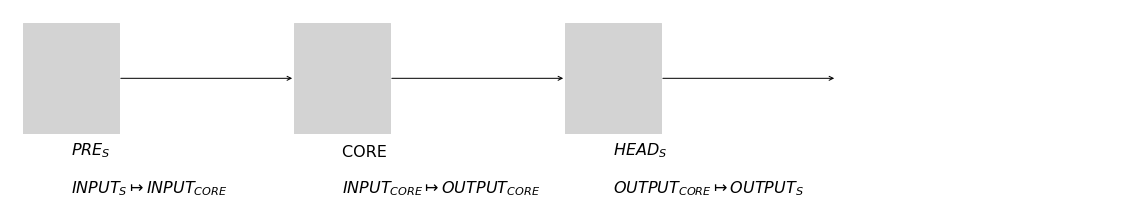

In [6]:
fig_tl

The Core model is "task-agnostic"
- general type for its INPUT and OUTPUT

A task-specific model $S$
- contains the CORE mode
- adds a pre-processor $\text{PRE}_S$
    - translates its input type $\text{INPUT}_S$ into the Core model's generic input type $\text{INPUT}_{CORE}$
- adds a task-specific $\text{HEAD}_S$
    - translate Core model's output type into task $S$ output type

## HuggingFace Model Hub

Let's see this in action on HuggingFace.

A pre-trained CORE model for the DistilBert architecture
- `class TFDistilBertPreTrainedModel(TFPreTrainedModel):`
- task agnostic

A task-specific sub-class for the Sequence Classification task    
- `class TFDistilBertForSequenceClassification(TFDistilBertPreTrainedModel, TFSequenceClassificationLoss):`
- includes a HEAD specialized to Sequence Classification

The head may be customizable
- vary the number of classes

but you are free to checkout a model without a head an append your own.

In HuggingFace, a model is named by a "checkpoint"

`checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"`
        
The checkpoint name is long because
- it specifies the characteristics of its training data
    - uncased, English
    - for the SST task
    
This Core model's checkpoint may be more difficult to adapt to
- non-English language text

Here we checkout a task-specific model

`model = TFAutoModelForSequenceClassification.from_pretrained(checkpoint)`

The `TF` prefix specifies that the model is a TensorFlow (rather than PyTorch) model.

The CORE model often has input type "tokens"
$$\text{INPUT}_\text{CORE} = \text{tokens}_\text{CORE}$$

- We subscript the tokens input of CORE
- because it was trained with a *specific* tokenizer

The CORE model often supplies a pre-processor from common input types to $\text{INPUT}_\text{CORE}$
- for example: $\text{text} \mapsto \text{tokens}_\text{CORE}$

Here we obtain a Pre-processor to convert text to the token-type of the specific checkpoint

        tokenizer = AutoTokenizer.from_pretrained(checkpoint)


Putting it all together

    import tensorflow as tf
    from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

    checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = TFAutoModelForSequenceClassification.from_pretrained(checkpoint)
    sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

    tokens = tokenizer(sequences, padding=True, truncation=True, return_tensors="tf")
    output = model(**tokens)

# Adapting the pre-trained model: Fine-tuning

# Weights

The CORE model has been pre-trained
- optimizing $\W_\text{CORE}$ for some Source task $S$
- using a large number of examples
- at high cost for training

The task-specific HEAD for target task $T$
- has untrained weights $\W_\text{HEAD}$



## Fine-tuning

In order to adapt the CORE model to target task $T$, we *fine-tune* it 
- Using a *small number* (compared to the pre-training size) of examples of the target task $T$

 $$
 \langle \x^{(1)}, \y^{(1)} \rangle, \ldots,  \langle \x^{(k)}, \y^{(k)}  \rangle
 $$

The purpose of fine-tuning is to
- optimize $\W_\text{HEAD}$ for target task $T$
- *potentially*
    - adapt $\W_\text{CORE}$ for target task $T$
    - be careful that fine-tuning does not completely *lose the knowledge* of the Source task
        - obtained at great expense !


In [7]:
print("Done")

Done
